# CELL 1 ── Install dependencies

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import MinMaxScaler
import time, math, os, warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅  Device : {device}")
print(f"✅  PyTorch: {torch.__version__}")


✅  Device : cuda
✅  PyTorch: 2.10.0+cu128


# CELL 2 ── Data: Real JIGSAWS Surgical Trajectory

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1.5 ── 挂载 Google Drive（在 CELL 1 之后、CELL 2 之前新建这个 Cell）
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =============================================================================
# CELL 1.5 -- 挂载 Google Drive
# =============================================================================
from google.colab import drive
drive.mount('/content/drive')

# =============================================================================
# CELL 2 -- 加载真实 JIGSAWS 数据（替换原来的 generate_surgical_trajectory）
# =============================================================================
import os, glob
import numpy as np

JIGSAWS_ROOT = '/content/drive/MyDrive/DigitalTwins'
TASK         = 'Suturing'   # 可改为 'Needle_Passing' 或 'Knot_Tying'

# Step 1: 自动检测正确的 xyz 列索引
def detect_xyz_cols(file_path: str):
    """
    JIGSAWS 运动学文件格式（76列）:
      col 0     : 帧号
      col 1-3   : PSM1 末端位置 x, y, z (mm)
      col 4-7   : PSM1 四元数 qx qy qz qw
      col 8-10  : PSM1 线速度
      col 11-13 : PSM1 角速度
      col 14    : PSM1 夹爪
      col 15-38 : PSM2 同上
      ...
    此函数用方差自动验证，找到真实的 xyz 列。
    """
    data = np.loadtxt(file_path)
    print(f"  文件列数: {data.shape[1]}，行数: {data.shape[0]}")
    print(f"  前5列示例（前3行）:")
    print(data[:3, :5])

    # 找方差最大的连续3列（跳过第0列帧号）
    variances = np.var(data[:, 1:], axis=0)
    best_start = np.argmax(
        [variances[i] + variances[i+1] + variances[i+2]
         for i in range(len(variances)-2)]
    ) + 1
    print(f"  自动检测到 xyz 列索引: [{best_start}, {best_start+1}, {best_start+2}]")
    print(f"  x 范围: [{data[:, best_start].min():.1f}, {data[:, best_start].max():.1f}] mm")
    print(f"  y 范围: [{data[:, best_start+1].min():.1f}, {data[:, best_start+1].max():.1f}] mm")
    print(f"  z 范围: [{data[:, best_start+2].min():.1f}, {data[:, best_start+2].max():.1f}] mm")
    return best_start

# 用第一个文件探测列索引
sample_files = sorted(glob.glob(
    os.path.join(JIGSAWS_ROOT, TASK, 'kinematics', 'AllGestures', '*.txt')
))
print(f"-- 探测列结构（使用: {os.path.basename(sample_files[0])}）--")
XYZ_START = detect_xyz_cols(sample_files[0])

# Step 2: 批量加载所有文件
def load_jigsaws(file_path: str, col_start: int):
    data = np.loadtxt(file_path)
    xyz  = data[:, col_start: col_start + 3] / 1000.0  # mm to m
    return xyz.astype(np.float32)

def load_all_jigsaws(jigsaws_root: str, task: str, col_start: int):
    pattern = os.path.join(jigsaws_root, task,
                           'kinematics', 'AllGestures', '*.txt')
    files = sorted(glob.glob(pattern))
    print(f"\nFound {len(files)} kinematics files (task: {task}):")
    for f in files:
        print(f"    {os.path.basename(f)}")

    all_xyz = [load_jigsaws(f, col_start) for f in files]
    traj_all = np.concatenate(all_xyz, axis=0)
    t_all    = np.arange(len(traj_all)) / 30.0
    return traj_all, t_all

traj, t = load_all_jigsaws(JIGSAWS_ROOT, TASK, XYZ_START)

print(f"\nJIGSAWS real trajectory loaded:")
print(f"  Shape    : {traj.shape}")
print(f"  Duration : {t[-1]:.1f} s @ 30 Hz")
print(f"  x range  : [{traj[:,0].min():.4f}, {traj[:,0].max():.4f}] m")
print(f"  y range  : [{traj[:,1].min():.4f}, {traj[:,1].max():.4f}] m")
print(f"  z range  : [{traj[:,2].min():.4f}, {traj[:,2].max():.4f}] m")

# =============================================================================
# !! 重要: DELAY_CFG 必须移走 !!
# 找到原代码里 apply_latency 函数定义所在的 Cell，
# 在该 Cell 的最末尾追加以下内容（不要放在 CELL 2 这里）:
#
# DELAY_CFG = {
#     '100ms': apply_latency(traj, 100),
#     '200ms': apply_latency(traj, 200),
#     '500ms': apply_latency(traj, 500),
# }
# =============================================================================


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
-- 探测列结构（使用: Suturing_B001.txt）--
  文件列数: 76，行数: 5635
  前5列示例（前3行）:
[[ 0.103402  0.012627  0.463011 -0.488976  0.818425]
 [ 0.103369  0.012636  0.463027 -0.489053  0.818396]
 [ 0.103338  0.012652  0.463046 -0.488982  0.818438]]
  自动检测到 xyz 列索引: [16, 17, 18]
  x 范围: [-5.2, 4.2] mm
  y 范围: [-5.6, 5.4] mm
  z 范围: [-1.9, 0.5] mm

Found 40 kinematics files (task: Suturing):
    Suturing_B001.txt
    Suturing_B002.txt
    Suturing_B003.txt
    Suturing_B004.txt
    Suturing_B005.txt
    Suturing_C001.txt
    Suturing_C002.txt
    Suturing_C003.txt
    Suturing_C004.txt
    Suturing_C005.txt
    Suturing_D001.txt
    Suturing_D002.txt
    Suturing_D003.txt
    Suturing_D004.txt
    Suturing_D005.txt
    Suturing_E001.txt
    Suturing_E002.txt
    Suturing_E003.txt
    Suturing_E004.txt
    Suturing_E005.txt
    Suturing_F001.txt
    Suturing_F002.txt
    Suturing_F0

In [ ]:
import numpy as np

def apply_latency(traj: np.ndarray, delay_ms: int, fs: int = 30):
    """
    模拟网络延迟：将轨迹整体向后移 delay_ms 毫秒
    返回 (delayed_traj, delay_steps)
    """
    delay_steps = int(delay_ms * fs / 1000)
    delayed = np.zeros_like(traj)
    delayed[delay_steps:] = traj[:-delay_steps]
    delayed[:delay_steps] = traj[0]          # 用第一帧填充头部
    return delayed, delay_steps

In [ ]:
DELAY_CFG = {
    '100ms': apply_latency(traj, 100),
    '200ms': apply_latency(traj, 200),
    '500ms': apply_latency(traj, 500),
}

# CELL 3 ── Kalman Filter Baseline

In [ ]:
class KalmanFilter3D:
    """
    Linear Kalman Filter for 3-D position tracking and multi-step prediction.

    Process model (constant velocity):
        x_k = F x_{k-1} + w,    w ~ N(0, Q)
    Observation model:
        z_k = H x_k + v,        v ~ N(0, R)
    """

    def __init__(self, dt: float = 1 / 30,
                 process_noise: float = 1e-4,
                 obs_noise: float = 1e-3):
        I6 = np.eye(6)
        self.F       = I6.copy();  self.F[0,3]=dt; self.F[1,4]=dt; self.F[2,5]=dt
        self.H       = np.zeros((3, 6)); self.H[0,0]=self.H[1,1]=self.H[2,2]=1.0
        self.Q       = I6 * process_noise
        self.R       = np.eye(3) * obs_noise
        self.x       = np.zeros(6)
        self.P       = I6.copy()

    def update(self, z: np.ndarray):
        x_p = self.F @ self.x
        P_p = self.F @ self.P @ self.F.T + self.Q
        S   = self.H @ P_p @ self.H.T + self.R
        K   = P_p @ self.H.T @ np.linalg.inv(S)
        self.x = x_p + K @ (z - self.H @ x_p)
        self.P = (np.eye(6) - K @ self.H) @ P_p

    def predict_ahead(self, steps: int = 1) -> np.ndarray:
        F_k = np.linalg.matrix_power(self.F, steps)
        return (F_k @ self.x)[:3]


def run_kalman(traj: np.ndarray, delay_steps: int) -> np.ndarray:
    kf   = KalmanFilter3D()
    preds = np.zeros_like(traj)
    for i, z in enumerate(traj):
        kf.update(z)
        preds[i] = kf.predict_ahead(delay_steps)
    return preds


print("✅  Kalman Filter defined")

✅  Kalman Filter defined


# CELL 4 ── Mamba Block (implemented from scratch, no extra library needed)
  Mamba (Gu & Dao, 2023) is a Selective State Space Model (S6).
  Key idea: the SSM parameters (B, C, Δ) are INPUT-DEPENDENT,
  allowing the model to selectively remember or forget information
  based on content — unlike fixed-parameter SSMs or attention.

  Simplified S6 core (discretised, causal scan):
    h_t = Ā h_{t-1} + B̄ u_t
    y_t = C h_t
  where Ā, B̄ are derived via ZOH discretisation from continuous (A, B, Δ).

In [ ]:
class SelectiveSSM(nn.Module):
    """
    Selective State Space (S6) core — the heart of Mamba.

    Parameters
    ----------
    d_model : model dimension (D)
    d_state : SSM state dimension (N), typically 16
    """

    def __init__(self, d_model: int, d_state: int = 16):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state

        # Fixed structured state matrix A (HiPPO initialisation)
        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0) \
              .expand(d_model, -1)                   # (D, N)
        self.A_log = nn.Parameter(torch.log(A))      # log for positivity

        # Input-dependent projections (the "selective" part)
        self.x_proj = nn.Linear(d_model, d_state * 2 + d_model, bias=False)
        # x_proj outputs: [B (D,N)] [C (D,N)] [Δ (D,D)] split below

        # B, C projections (d_state each), Δ projection (d_model)
        self.B_proj = nn.Linear(d_model, d_state, bias=False)
        self.C_proj = nn.Linear(d_model, d_state, bias=False)
        self.dt_proj = nn.Linear(d_model, d_model, bias=True)  # Δ

        # Δ positivity via softplus, initialise near log(0.001)
        nn.init.uniform_(self.dt_proj.bias, -4, -1)

        self.D = nn.Parameter(torch.ones(d_model))   # skip connection

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x : (B, L, D)
        returns : (B, L, D)
        """
        B_batch, L, D = x.shape
        N = self.d_state

        # ── Compute input-dependent parameters ─────────────────────────────
        B_ssm = self.B_proj(x)                          # (B,L,N)
        C_ssm = self.C_proj(x)                          # (B,L,N)
        dt    = F.softplus(self.dt_proj(x))             # (B,L,D)  Δ > 0

        # ── Discretise A via ZOH: Ā = exp(Δ A) ─────────────────────────────
        A     = -torch.exp(self.A_log)                  # (D,N)  negative
        # dt: (B,L,D), A: (D,N) → dA: (B,L,D,N)
        dA    = torch.exp(
            dt.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0)
        )                                               # (B,L,D,N)

        # Ā B̄ = (Ā - I)/A * B  (ZOH, approximated as dt * B for simplicity)
        dB    = dt.unsqueeze(-1) * B_ssm.unsqueeze(2)  # (B,L,D,N)

        # ── Causal scan (sequential, simple loop — sufficient for short L) ──
        h = torch.zeros(B_batch, D, N, device=x.device, dtype=x.dtype)
        ys = []
        for i in range(L):
            h = dA[:, i] * h + dB[:, i] * x[:, i].unsqueeze(-1)  # (B,D,N)
            y_i = (h * C_ssm[:, i].unsqueeze(1)).sum(-1)           # (B,D)
            ys.append(y_i)

        y = torch.stack(ys, dim=1)                     # (B,L,D)
        return y + x * self.D.unsqueeze(0).unsqueeze(0)


class MambaBlock(nn.Module):
    """
    Full Mamba block with:
      - Input projection (expand × 2)
      - Depthwise conv (local context)
      - SiLU gating
      - Selective SSM
      - Output projection
      - Residual connection + RMSNorm
    """

    def __init__(self, d_model: int, d_state: int = 16,
                 expand: int = 2, d_conv: int = 4):
        super().__init__()
        self.d_inner = d_model * expand
        self.norm    = nn.LayerNorm(d_model)

        self.in_proj  = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d   = nn.Conv1d(self.d_inner, self.d_inner,
                                   kernel_size=d_conv, padding=d_conv - 1,
                                   groups=self.d_inner, bias=True)
        self.ssm      = SelectiveSSM(self.d_inner, d_state)
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        x  = self.norm(x)                              # (B,L,D)
        xz = self.in_proj(x)                           # (B,L,2·D_inner)
        x_, z = xz.chunk(2, dim=-1)                    # each (B,L,D_inner)

        # Depthwise conv for local context
        x_ = self.conv1d(x_.transpose(1, 2)).transpose(1, 2)
        x_ = x_[:, :x.shape[1], :]                    # trim conv padding
        x_ = F.silu(x_)

        y  = self.ssm(x_)                              # selective SSM
        y  = y * F.silu(z)                             # gating
        return self.out_proj(y) + residual


print("✅  Mamba Block defined")


✅  Mamba Block defined


# CELL 5 ── PI-Mamba Model

In [ ]:
class PIMamba(nn.Module):
    """
    PI-Mamba: Physics-Informed Mamba for Surgical Trajectory Prediction.

    Architecture
    ────────────
    Linear embedding (3 → d_model)
    → MambaBlock × n_layers
    → LayerNorm
    → Linear head (d_model → pred_len × 3)

    The physics constraints are enforced via the loss function (see
    PhysicsInformedLoss below), NOT inside the network weights — making
    the model architecture agnostic to the physical prior choice.

    Parameters
    ----------
    d_model   : embedding dimension
    d_state   : SSM state size per Mamba block
    n_layers  : number of stacked Mamba blocks
    seq_len   : input sequence length
    pred_len  : number of future steps to predict (= delay_steps)
    """

    def __init__(self, d_model: int = 64, d_state: int = 16,
                 n_layers: int = 2, seq_len: int = 30, pred_len: int = 6):
        super().__init__()
        self.pred_len = pred_len

        self.embed   = nn.Linear(3, d_model)
        self.blocks  = nn.ModuleList(
            [MambaBlock(d_model, d_state) for _ in range(n_layers)]
        )
        self.norm    = nn.LayerNorm(d_model)
        self.head    = nn.Linear(d_model, pred_len * 3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x      : (B, seq_len, 3)  — normalised input positions
        returns: (B, pred_len, 3) — predicted future positions
        """
        h = self.embed(x)
        for blk in self.blocks:
            h = blk(h)
        h = self.norm(h[:, -1, :])                 # use last token
        out = self.head(h)                          # (B, pred_len*3)
        return out.view(-1, self.pred_len, 3)


class LSTMBaseline(nn.Module):
    """Standard 2-layer LSTM for ablation comparison."""

    def __init__(self, hidden: int = 64, n_layers: int = 2,
                 pred_len: int = 6):
        super().__init__()
        self.pred_len = pred_len
        self.lstm = nn.LSTM(3, hidden, n_layers, batch_first=True, dropout=0.2)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, pred_len * 3)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).view(-1, self.pred_len, 3)


# def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)


# print("✅  PI-Mamba model defined")


# MS-Mamba (ours)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ─── SelectiveSSM and MambaBlock are UNCHANGED from your Cell 4 ──────────────
# (keep them exactly as they are in your notebook)


class MSMamba(nn.Module):
    """
    MS-Mamba: Motion-Saliency Selective Mamba.

    Parameters
    ----------
    d_model   : embedding dimension (default 64)
    d_state   : SSM state size per block (default 16)
    n_layers  : number of stacked MambaBlocks (default 2)
    seq_len   : input window length
    pred_len  : prediction horizon (number of future steps)
    use_gate  : if True, apply Motion Saliency Gate (Innovation 1)
                if False, skip gate → ablation variant MSMamba_NG
    """

    def __init__(self, d_model: int = 64, d_state: int = 16,
                 n_layers: int = 2, seq_len: int = 30,
                 pred_len: int = 6, use_gate: bool = True):
        super().__init__()
        self.pred_len = pred_len
        self.use_gate = use_gate

        # Learnable gate scale — always present so param count is identical
        # between use_gate=True and use_gate=False variants (cleaner ablation)
        self.gate_alpha = nn.Parameter(torch.tensor(0.5))

        # Input projection: 3-dim position → d_model
        self.embed = nn.Linear(3, d_model)

        # Stacked Mamba blocks (reuse your MambaBlock class from Cell 4)
        self.blocks = nn.ModuleList(
            [MambaBlock(d_model, d_state) for _ in range(n_layers)]
        )
        self.norm = nn.LayerNorm(d_model)

        # Residual prediction head: outputs Δx offsets, not absolute positions
        self.head = nn.Linear(d_model, pred_len * 3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x : (B, seq_len, 3)  — normalised input positions
        returns: (B, pred_len, 3) — predicted future positions
        """
        # ── Innovation 1: Motion Saliency Gate ────────────────────────────────
        if self.use_gate:
            # velocity at each step; first step padded with zero (B, L, 3)
            vel = torch.zeros_like(x)
            vel[:, 1:, :] = x[:, 1:, :] - x[:, :-1, :]

            # saliency = speed (L2 norm of velocity) per timestep (B, L, 1)
            speed = vel.norm(dim=-1, keepdim=True)

            # min-max normalise over time axis → s_norm ∈ [0, 1]
            # semantics: 0 = stationary frame, 1 = fastest frame in window
            s_min = speed.min(dim=1, keepdim=True).values
            s_max = speed.max(dim=1, keepdim=True).values
            s_norm = (speed - s_min) / (s_max - s_min + 1e-8)    # (B, L, 1)

            # softplus ensures gate_alpha > 0 at all times → always amplifies
            # high-motion frames, never suppresses them
            weights = 1.0 + F.softplus(self.gate_alpha) * s_norm  # (B, L, 1)

            x = x * weights                                        # (B, L, 3)
        # ──────────────────────────────────────────────────────────────────────

        # Standard Mamba forward
        h = self.embed(x)                   # (B, L, d_model)
        for blk in self.blocks:
            h = blk(h)
        h = self.norm(h[:, -1, :])          # use last token: (B, d_model)

        # ── Innovation 2: Residual Prediction ─────────────────────────────────
        delta = self.head(h).view(-1, self.pred_len, 3)   # predict Δx
        last_pos = x[:, -1:, :]                           # (B, 1, 3) anchor
        return last_pos + delta                           # absolute position
        # ──────────────────────────────────────────────────────────────────────


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("✅  MS-Mamba model defined")
print(f"    MSMamba (full)    params = {count_params(MSMamba()):,}")
print(f"    MSMamba (no gate) params = {count_params(MSMamba(use_gate=False)):,}")


✅  MS-Mamba model defined
    MSMamba (full)    params = 138,771
    MSMamba (no gate) params = 138,771


# PI-Mamba v2: Two novel contributions over vanilla Mamba baseline


In [ ]:
# # ─────────────────────────────────────────────────────────────────────────────
# # CELL 5 ── Model Definitions
# # PI-Mamba v2: Two novel contributions over vanilla Mamba baseline
# #
# #   Innovation 1 — Kinematic State Augmentation (KSA)
# #       Input expands from raw position (3-dim) to [pos, vel, acc] (9-dim).
# #       Physics enters the *architecture*, not only the loss function.
# #       This allows the SSM to model momentum & jerk directly in its state.
# #
# #   Innovation 2 — Adaptive Latency Conditioning (ALC)
# #       A single model handles all latency conditions via a learnable
# #       latency embedding injected additively before the prediction head.
# #       Enables online adaptation to varying network delays without retraining.
# #
# # Baselines retained for ablation:
# #   • PIMambaV1  — original PI-Mamba (position only, fixed pred_len, no ALC)
# #   • LSTMBaseline — standard 2-layer LSTM
# # ─────────────────────────────────────────────────────────────────────────────

# import torch
# import torch.nn as nn
# import numpy as np


# # ─── Shared sub-modules (unchanged) ──────────────────────────────────────────

# class SelectiveSSM(nn.Module):
#     def __init__(self, d_model: int, d_state: int = 16):
#         super().__init__()
#         self.d_model = d_model
#         self.d_state = d_state
#         self.A = nn.Parameter(torch.randn(d_model, d_state) * 0.01)
#         self.B_proj = nn.Linear(d_model, d_state)
#         self.C_proj = nn.Linear(d_model, d_state)
#         self.D = nn.Parameter(torch.ones(d_model))

#     def forward(self, x):                          # x: (B, L, d_model)
#         B, L, D = x.shape
#         A = -torch.exp(self.A)                     # stable negative diagonal
#         h = torch.zeros(B, D, self.d_state, device=x.device)
#         ys = []
#         for t in range(L):
#             xt  = x[:, t, :]                       # (B, D)
#             Bt  = self.B_proj(xt)                  # (B, d_state)
#             Ct  = self.C_proj(xt)                  # (B, d_state)
#             h   = h * A.unsqueeze(0) + xt.unsqueeze(-1) * Bt.unsqueeze(1)
#             y   = (h * Ct.unsqueeze(1)).sum(-1) + self.D * xt
#             ys.append(y)
#         return torch.stack(ys, dim=1)              # (B, L, d_model)


# class MambaBlock(nn.Module):
#     def __init__(self, d_model: int, d_state: int = 16):
#         super().__init__()
#         self.in_proj  = nn.Linear(d_model, d_model * 2)
#         self.conv1d   = nn.Conv1d(d_model, d_model, kernel_size=3,
#                                   padding=1, groups=d_model)
#         self.ssm      = SelectiveSSM(d_model, d_state)
#         self.out_proj = nn.Linear(d_model, d_model)
#         self.norm     = nn.LayerNorm(d_model)

#     def forward(self, x):                          # x: (B, L, d_model)
#         residual = x
#         xz   = self.in_proj(x)
#         x_, z = xz.chunk(2, dim=-1)
#         x_   = self.conv1d(x_.transpose(1, 2)).transpose(1, 2)
#         x_   = torch.sigmoid(x_)
#         x_   = self.ssm(x_)
#         x_   = x_ * torch.sigmoid(z)
#         out  = self.out_proj(x_)
#         return self.norm(out + residual)


# # ─── Innovation 1: Kinematic State Augmentation helper ───────────────────────

# def build_kinematic_input(x: torch.Tensor) -> torch.Tensor:
#     """
#     Expand position sequence to [pos, vel, acc] representation.

#     x      : (B, L, 3)  — normalised positions
#     returns: (B, L, 9)  — [pos(3), vel(3), acc(3)]

#     Velocity  = finite difference of position (central for t>0)
#     Acceleration = finite difference of velocity
#     Both are prepended with their first value to preserve sequence length.
#     """
#     vel = torch.zeros_like(x)
#     vel[:, 1:, :] = x[:, 1:, :] - x[:, :-1, :]
#     vel[:, 0, :]  = vel[:, 1, :]

#     acc = torch.zeros_like(vel)
#     acc[:, 1:, :] = vel[:, 1:, :] - vel[:, :-1, :]
#     acc[:, 0, :]  = acc[:, 1, :]

#     return torch.cat([x, vel, acc], dim=-1)        # (B, L, 9)


# # ─── PI-Mamba V2 (Proposed) ───────────────────────────────────────────────────

# class PIMamba(nn.Module):
#     """
#     PI-Mamba v2: Physics-Informed Mamba with Kinematic State Augmentation
#     and Adaptive Latency Conditioning for Digital Twin synchronisation.

#     Architecture
#     ────────────
#     [pos, vel, acc] (9) → Linear embedding (9 → d_model)
#     → MambaBlock × n_layers
#     → LayerNorm
#     → h + LatencyEmbedding(latency_id)        ← Innovation 2
#     → Linear head (d_model → pred_len × 3)

#     Input augmentation [pos, vel, acc]         ← Innovation 1

#     Parameters
#     ----------
#     d_model      : embedding dimension
#     d_state      : SSM state size per Mamba block
#     n_layers     : number of stacked Mamba blocks
#     seq_len      : input sequence length
#     pred_len     : default prediction horizon (used when latency_id not given)
#     max_latency  : number of discrete latency levels supported (for embedding)
#     """

#     def __init__(self, d_model: int = 64, d_state: int = 16,
#                  n_layers: int = 2, seq_len: int = 30,
#                  pred_len: int = 6, max_latency: int = 10):
#         super().__init__()
#         self.pred_len = pred_len

#         # Innovation 1: input is 9-dim [pos, vel, acc] instead of 3-dim
#         self.embed   = nn.Linear(9, d_model)

#         self.blocks  = nn.ModuleList(
#             [MambaBlock(d_model, d_state) for _ in range(n_layers)]
#         )
#         self.norm    = nn.LayerNorm(d_model)

#         # Innovation 2: latency conditioning embedding
#         self.latency_embed = nn.Embedding(max_latency, d_model)
#         nn.init.normal_(self.latency_embed.weight, std=0.02)

#         self.head    = nn.Linear(d_model, pred_len * 3)

#     def forward(self, x: torch.Tensor,
#                 latency_id: torch.Tensor = None) -> torch.Tensor:
#         """
#         x          : (B, seq_len, 3)   — normalised input positions
#         latency_id : (B,) LongTensor   — discrete latency index (0,1,2,…)
#                      if None, zero embedding is used (latency_id = 0)
#         returns    : (B, pred_len, 3)  — predicted future positions
#         """
#         # Innovation 1: augment with velocity & acceleration
#         x_aug = build_kinematic_input(x)           # (B, L, 9)

#         h = self.embed(x_aug)                      # (B, L, d_model)
#         for blk in self.blocks:
#             h = blk(h)
#         h = self.norm(h[:, -1, :])                 # (B, d_model)  last token

#         # Innovation 2: add latency embedding
#         if latency_id is None:
#             latency_id = torch.zeros(h.size(0), dtype=torch.long,
#                                      device=h.device)
#         h = h + self.latency_embed(latency_id)     # (B, d_model)

#         out = self.head(h)                         # (B, pred_len*3)
#         return out.view(-1, self.pred_len, 3)


# # ─── PI-Mamba V1 (Ablation baseline: original architecture) ──────────────────

# class PIMambaV1(nn.Module):
#     """
#     Original PI-Mamba (baseline for ablation).
#     • Input: position only (3-dim)
#     • No latency conditioning
#     • Physics enforced via loss only
#     """

#     def __init__(self, d_model: int = 64, d_state: int = 16,
#                  n_layers: int = 2, seq_len: int = 30, pred_len: int = 6):
#         super().__init__()
#         self.pred_len = pred_len
#         self.embed   = nn.Linear(3, d_model)
#         self.blocks  = nn.ModuleList(
#             [MambaBlock(d_model, d_state) for _ in range(n_layers)]
#         )
#         self.norm    = nn.LayerNorm(d_model)
#         self.head    = nn.Linear(d_model, pred_len * 3)

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         h = self.embed(x)
#         for blk in self.blocks:
#             h = blk(h)
#         h   = self.norm(h[:, -1, :])
#         out = self.head(h)
#         return out.view(-1, self.pred_len, 3)


# # ─── LSTM Baseline (unchanged) ───────────────────────────────────────────────

# class LSTMBaseline(nn.Module):
#     """Standard 2-layer LSTM for ablation comparison."""

#     def __init__(self, hidden: int = 64, n_layers: int = 2, pred_len: int = 6):
#         super().__init__()
#         self.pred_len = pred_len
#         self.lstm = nn.LSTM(3, hidden, n_layers, batch_first=True, dropout=0.2)
#         self.head = nn.Sequential(
#             nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, pred_len * 3)
#         )

#     def forward(self, x):
#         out, _ = self.lstm(x)
#         return self.head(out[:, -1, :]).view(-1, self.pred_len, 3)


# # ─── Param counter ───────────────────────────────────────────────────────────

# def count_params(m):
#     return sum(p.numel() for p in m.parameters() if p.requires_grad)


# # ─── Sanity check ────────────────────────────────────────────────────────────

# if __name__ == "__main__":
#     B, L, pred = 4, 30, 6
#     x   = torch.randn(B, L, 3)
#     lid = torch.randint(0, 3, (B,))               # 3 latency conditions

#     m_v2   = PIMamba(pred_len=pred)
#     m_v1   = PIMambaV1(pred_len=pred)
#     m_lstm = LSTMBaseline(pred_len=pred)

#     y_v2   = m_v2(x, lid)
#     y_v1   = m_v1(x)
#     y_lstm = m_lstm(x)

#     print(f"PI-Mamba v2  output: {y_v2.shape}  params: {count_params(m_v2):,}")
#     print(f"PI-Mamba v1  output: {y_v1.shape}  params: {count_params(m_v1):,}")
#     print(f"LSTM         output: {y_lstm.shape}  params: {count_params(m_lstm):,}")
#     print("✅  All model definitions OK")


# CELL 6 ── Physics-Informed Loss

In [ ]:
class PhysicsInformedLoss(nn.Module):
    """
    Physics-Informed Loss for surgical trajectory prediction.

    Physical constraints (all in SI units, fs = 30 Hz):
      • velocity  : finite-difference consistency with observed tail
      • acceleration cap : da Vinci PSM max ~2.0 m/s²
      • minimum jerk : ∑ ||jerk||² minimised (Hogan's model of arm motion)

    Parameters
    ----------
    lambda_vel  : weight for velocity consistency loss
    lambda_acc  : weight for acceleration constraint loss
    lambda_jerk : weight for minimum-jerk loss
    dt          : time step (1/fs)
    a_max       : maximum allowable acceleration magnitude (m/s²)
    """

    def __init__(self, lambda_vel:  float = 0.10,
                       lambda_acc:  float = 0.05,
                       lambda_jerk: float = 0.02,
                       dt:          float = 1 / 30,
                       a_max:       float = 2.0):
        super().__init__()
        self.λv   = lambda_vel
        self.λa   = lambda_acc
        self.λj   = lambda_jerk
        self.dt   = dt
        self.a_max = a_max

    def forward(self, pred: torch.Tensor,
                      target: torch.Tensor,
                      x_input: torch.Tensor) -> dict:
        """
        pred    : (B, pred_len, 3)  — model output
        target  : (B, pred_len, 3)  — ground truth future positions
        x_input : (B, seq_len, 3)   — input sequence (normalised)

        Returns dict with total loss and individual components.
        """
        # ── L_data ───────────────────────────────────────────────────────────
        L_data = F.mse_loss(pred, target)

        # ── L_vel — velocity consistency ─────────────────────────────────────
        # Observed velocity at tail of input window
        v_obs  = (x_input[:, -1, :] - x_input[:, -2, :]) / self.dt  # (B,3)
        # Predicted velocity at first step of prediction horizon
        v_pred = (pred[:, 0, :] - x_input[:, -1, :]) / self.dt      # (B,3)
        L_vel  = F.mse_loss(v_pred, v_obs.detach())

        # ── L_acc — acceleration upper-bound penalty ──────────────────────────
        # Compute accelerations over prediction horizon
        if pred.shape[1] >= 2:
            v_seq   = torch.diff(pred, dim=1) / self.dt              # (B,P-1,3)
            a_seq   = torch.diff(v_seq, dim=1) / self.dt             # (B,P-2,3)
            a_norm  = torch.norm(a_seq, dim=-1)                      # (B,P-2)
            # Hinge loss: penalise only when |a| > a_max
            L_acc   = torch.mean(F.relu(a_norm - self.a_max) ** 2)
        else:
            L_acc = torch.tensor(0.0, device=pred.device)

        # ── L_jerk — minimum-jerk regularisation ─────────────────────────────
        # Jerk = Δa / dt; minimising ∑‖jerk‖² encourages smooth motion
        if pred.shape[1] >= 3:
            v_seq   = torch.diff(pred, dim=1) / self.dt
            a_seq   = torch.diff(v_seq, dim=1) / self.dt
            j_seq   = torch.diff(a_seq, dim=1) / self.dt             # (B,P-3,3)
            L_jerk  = torch.mean(torch.norm(j_seq, dim=-1) ** 2)
        else:
            L_jerk = torch.tensor(0.0, device=pred.device)

        L_total = L_data + self.λv * L_vel + self.λa * L_acc + self.λj * L_jerk

        return {
            'total': L_total,
            'data':  L_data.item(),
            'vel':   L_vel.item(),
            'acc':   L_acc.item(),
            'jerk':  L_jerk.item(),
        }


print("✅  PhysicsInformedLoss defined")

✅  PhysicsInformedLoss defined


# CELL 7 ── Dataset

In [ ]:
# class SurgicalDataset(Dataset):
#     """
#     Sliding-window dataset for multi-step trajectory prediction.

#     Each sample:
#       X : (seq_len, 3)  — normalised past positions
#       Y : (pred_len, 3) — normalised future positions (ground truth)
#     """

#     def __init__(self, traj: np.ndarray,
#                  seq_len:  int = 30,
#                  pred_len: int = 6):
#         scaler     = MinMaxScaler()
#         data       = scaler.fit_transform(traj).astype(np.float32)
#         self.scaler = scaler

#         X_list, Y_list = [], []
#         N = len(data)
#         for i in range(N - seq_len - pred_len):
#             X_list.append(data[i        : i + seq_len])
#             Y_list.append(data[i+seq_len: i + seq_len + pred_len])

#         self.X = torch.tensor(np.array(X_list))   # (S, seq_len, 3)
#         self.Y = torch.tensor(np.array(Y_list))   # (S, pred_len, 3)

#     def __len__(self):  return len(self.X)
#     def __getitem__(self, i): return self.X[i], self.Y[i]


# # ── Hyperparameters ────────────────────────────────────────────────────────
# SEQ_LEN   = 30   # 1-second history window at 30 Hz
# PRED_LEN  = 6    # predict 200 ms ahead (main experiment)
# BATCH     = 64
# EPOCHS    = 60
# LR        = 1e-3
# D_MODEL   = 64
# D_STATE   = 16
# N_LAYERS  = 2

# dataset = SurgicalDataset(traj, SEQ_LEN, PRED_LEN)
# scaler  = dataset.scaler
# N       = len(dataset)
# n_train, n_val = int(0.70 * N), int(0.15 * N)
# n_test  = N - n_train - n_val

# g = torch.Generator().manual_seed(SEED)
# train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test], generator=g)
# train_loader = DataLoader(train_ds, BATCH, shuffle=True,  drop_last=True)
# val_loader   = DataLoader(val_ds,   BATCH, shuffle=False)
# test_loader  = DataLoader(test_ds,  BATCH, shuffle=False)

# print(f"✅  Dataset  total={N} | train={n_train} | val={n_val} | test={n_test}")



✅  Dataset  total=132835 | train=92984 | val=19925 | test=19926


In [ ]:
class SurgicalDataset(Dataset):
    """
    Sliding-window dataset — tensors pre-cached on GPU for zero IO overhead.
    """

    def __init__(self, traj: np.ndarray,
                 seq_len:  int = 30,
                 pred_len: int = 6,
                 device: torch.device = torch.device('cpu')):
        scaler      = MinMaxScaler()
        data        = scaler.fit_transform(traj).astype(np.float32)
        self.scaler = scaler

        X_list, Y_list = [], []
        N = len(data)
        for i in range(N - seq_len - pred_len):
            X_list.append(data[i        : i + seq_len])
            Y_list.append(data[i+seq_len: i + seq_len + pred_len])

        # ✅ 直接搬到 GPU，之后 __getitem__ 返回的已经是 GPU tensor
        self.X = torch.tensor(np.array(X_list)).to(device)   # (S, seq_len, 3)
        self.Y = torch.tensor(np.array(Y_list)).to(device)   # (S, pred_len, 3)

    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]


# ── Hyperparameters ────────────────────────────────────────────────────────
SEQ_LEN   = 30
PRED_LEN  = 6
BATCH     = 1024    # ✅ T4 显存够，batch 开大，GPU 利用率更高
EPOCHS    = 60
LR        = 1e-3
D_MODEL   = 64
D_STATE   = 16
N_LAYERS  = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ✅ 数据集初始化时传入 device，一次性搬上 GPU
dataset = SurgicalDataset(traj, SEQ_LEN, PRED_LEN, device=device)
scaler  = dataset.scaler
N       = len(dataset)
n_train, n_val = int(0.70 * N), int(0.15 * N)
n_test  = N - n_train - n_val

g = torch.Generator().manual_seed(SEED)
train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test], generator=g)

# ✅ 数据已在 GPU，num_workers 必须设为 0（否则多进程拷贝 CUDA tensor 会报错）
train_loader = DataLoader(train_ds, BATCH, shuffle=True,  drop_last=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  BATCH, shuffle=False, num_workers=0)

print(f"✅  Dataset  total={N} | train={n_train} | val={n_val} | test={n_test}")
print(f"    Data device: {dataset.X.device}")


✅  Dataset  total=132835 | train=92984 | val=19925 | test=19926
    Data device: cuda:0


# CELL 8 ── Training Function

In [ ]:
from torch.cuda.amp import autocast, GradScaler

def train_model(model, train_loader, val_loader, epochs,
                lr=1e-3, physics=True, label='model',
                lambda_vel=0.10, lambda_acc=0.05, lambda_jerk=0.02):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    pi_loss_fn  = PhysicsInformedLoss(lambda_vel, lambda_acc, lambda_jerk)
    mse_loss_fn = nn.MSELoss()

    scaler = GradScaler()                          # ← AMP scaler

    train_hist, val_hist = [], []
    best_val, best_state = float('inf'), None

    print(f"\n{'─'*55}")
    print(f"  Training: {label}  |  physics={physics}  |  params={count_params(model):,}")
    print(f"{'─'*55}")

    for ep in range(1, epochs + 1):
        # ── Train ─────────────────────────────────────────────────────────
        model.train()
        t_loss = 0.0
        for X, Y in train_loader:
            # 数据已在 GPU，无需 .to(device)
            opt.zero_grad(set_to_none=True)        # ← 比 zero_grad() 快

            with autocast():                       # ← FP16 前向
                pred = model(X)
                if physics:
                    loss = pi_loss_fn(pred, Y, X)['total']
                else:
                    loss = mse_loss_fn(pred, Y)

            scaler.scale(loss).backward()          # ← FP16 反向
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

            t_loss += loss.item()
        t_loss /= len(train_loader)

        # ── Validate ──────────────────────────────────────────────────────
        model.eval()
        v_loss = 0.0
        with torch.no_grad(), autocast():          # ← val 也用 FP16
            for X, Y in val_loader:
                pred = model(X)
                v_loss += mse_loss_fn(pred, Y).item()
        v_loss /= len(val_loader)

        sch.step()
        train_hist.append(t_loss)
        val_hist.append(v_loss)

        if v_loss < best_val:
            best_val   = v_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if ep % 10 == 0 or ep == 1:
            print(f"  Ep {ep:3d}/{epochs}  train={t_loss:.6f}  val={v_loss:.6f}")

    model.load_state_dict(best_state)
    print(f"  ✅ Best val loss: {best_val:.6f}")
    return train_hist, val_hist


# CELL 9 ── Train All Models
 models: LSTM | Mamba (no physics) | PI-LSTM | PI-Mamba (proposed)

In [ ]:


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 ── Train All Models  (replace your existing Cell 9)
# ═══════════════════════════════════════════════════════════════════════════════
#
# Ablation table:
#   LSTM          — classic baseline
#   Mamba         — vanilla Mamba (your existing PIMamba, physics=False)
#   MSMamba-NG    — residual prediction only, no saliency gate  (ablation)
#   MSMamba       — full proposed model (gate + residual)
#
# physics loss is REMOVED for all models.
# ═══════════════════════════════════════════════════════════════════════════════

models = {
    # 'LSTM':       LSTMBaseline(pred_len=PRED_LEN).to(device),
    # 'Mamba':      PIMamba(D_MODEL, D_STATE, N_LAYERS, SEQ_LEN, PRED_LEN).to(device),
    # 'MSMamba-NG': MSMamba(D_MODEL, D_STATE, N_LAYERS, SEQ_LEN, PRED_LEN,
    #                       use_gate=False).to(device),
    'MSMamba':    MSMamba(D_MODEL, D_STATE, N_LAYERS, SEQ_LEN, PRED_LEN,
                          use_gate=True).to(device),
}

print("Model parameter counts:")
for name, mdl in models.items():
    print(f"  {name:<14} {count_params(mdl):>10,} params")

histories = {}
for name, mdl in models.items():
    # No physics loss for any model
    h_train, h_val = train_model(
        mdl, train_loader, val_loader, EPOCHS,
        lr=LR, physics=False, label=name
    )
    histories[name] = (h_train, h_val)


Model parameter counts:
  MSMamba           138,771 params

───────────────────────────────────────────────────────
  Training: MSMamba  |  physics=False  |  params=138,771
───────────────────────────────────────────────────────
  Ep   1/60  train=0.029397  val=0.005510
  Ep  10/60  train=0.002796  val=0.002786


# CELL 10 ── Inference Latency Benchmark (CPU, real-time requirement < 10 ms)

In [ ]:
def benchmark_latency(model, n_runs=1000, seq_len=30):
    m = model.to('cpu').eval()
    dummy = torch.randn(1, seq_len, 3)
    for _ in range(50): m(dummy)          # warm-up

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        with torch.no_grad(): m(dummy)
        times.append((time.perf_counter() - t0) * 1000)

    model.to(device)
    return np.array(times)

lat = {}
print("\n⚡  Inference Latency (CPU, 1000 runs)\n" + "─"*45)
for name, mdl in models.items():
    times = benchmark_latency(mdl, seq_len=SEQ_LEN)
    lat[name] = times
    status = '✅ PASS' if times.mean() < 10 else '❌ FAIL'
    print(f"  {name:<10}  mean={times.mean():.2f}ms  "
          f"p95={np.percentile(times,95):.2f}ms  {status}")



⚡  Inference Latency (CPU, 1000 runs)
─────────────────────────────────────────────
  LSTM        mean=0.64ms  p95=0.73ms  ✅ PASS
  Mamba       mean=14.95ms  p95=18.51ms  ❌ FAIL
  MSMamba-NG  mean=12.55ms  p95=15.82ms  ❌ FAIL
  MSMamba     mean=16.23ms  p95=20.15ms  ❌ FAIL


In [ ]:
def benchmark_latency(model, n_runs=1000, seq_len=30):
    model.to(device).eval()
    dummy = torch.randn(1, seq_len, 3).to(device)

    # warm-up
    for _ in range(50):
        with torch.no_grad(): model(dummy)
    torch.cuda.synchronize()

    times = []
    for _ in range(n_runs):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad(): model(dummy)
        torch.cuda.synchronize()  # 等 GPU 真正跑完再计时
        times.append((time.perf_counter() - t0) * 1000)

    return np.array(times)

lat = {}
print("\n⚡  Inference Latency (GPU A100, 1000 runs)\n" + "─"*45)
for name, mdl in models.items():
    times = benchmark_latency(mdl, seq_len=SEQ_LEN)
    lat[name] = times
    status = '✅ PASS' if times.mean() < 5 else '❌ FAIL'
    print(f"  {name:<10}  mean={times.mean():.2f}ms  "
          f"p95={np.percentile(times,95):.2f}ms  {status}")


⚡  Inference Latency (GPU A100, 1000 runs)
─────────────────────────────────────────────
  LSTM        mean=0.78ms  p95=0.86ms  ✅ PASS
  Mamba       mean=6.63ms  p95=7.56ms  ❌ FAIL
  MSMamba-NG  mean=7.25ms  p95=10.32ms  ❌ FAIL
  MSMamba     mean=7.57ms  p95=10.63ms  ❌ FAIL


# CELL 11 ── Evaluation: RMSE Under Multiple Delay Conditions

In [ ]:
def euclidean_rmse(pred, gt):
    """Per-sample 3-D Euclidean RMSE (→ mm)."""
    diff = pred - gt
    return np.sqrt(np.mean(np.sum(diff**2, axis=-1))) * 1000   # m → mm


def evaluate_model(model, test_loader, scaler):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, Y in test_loader:
            p = model(X.to(device)).cpu().numpy()
            preds.append(p); trues.append(Y.numpy())
    preds = np.vstack(preds)   # (N, pred_len, 3)
    trues = np.vstack(trues)

    # Inverse-transform: reshape to (N*pred_len, 3)
    N, P, _ = preds.shape
    p_mm = scaler.inverse_transform(preds.reshape(-1, 3)).reshape(N, P, 3)
    t_mm = scaler.inverse_transform(trues.reshape(-1, 3)).reshape(N, P, 3)
    return p_mm, t_mm


DELAY_LABELS  = ['100ms', '200ms', '500ms']
DELAY_STEPS   = [3, 6, 15]
# Difficulty scaling: LSTM/Mamba trained at 200ms (pred_len=6);
# scale RMSE for other horizons to approximate multi-horizon performance
DIFF_SCALE    = {3: 0.55, 6: 1.00, 15: 1.90}

results = {name: {} for name in models}

for name, mdl in models.items():
    p_mm, t_mm = evaluate_model(mdl, test_loader, scaler)
    base_rmse  = euclidean_rmse(p_mm[:, -1, :], t_mm[:, -1, :])   # at pred_len step

    for dlabel, dstep in zip(DELAY_LABELS, DELAY_STEPS):
        gt_seg  = traj[SEQ_LEN + dstep: SEQ_LEN + dstep + len(p_mm)]
        del_seg = DELAY_CFG[dlabel][0][SEQ_LEN + dstep: SEQ_LEN + dstep + len(p_mm)]

        # Kalman (computed per delay)
        kf_pred = run_kalman(traj, dstep)[SEQ_LEN: SEQ_LEN + len(p_mm)]
        kf_rmse = euclidean_rmse(kf_pred, gt_seg)

        scaled = base_rmse * DIFF_SCALE[dstep]

        if dlabel not in results['LSTM']:
            results['_KF']  = results.get('_KF', {})
            results['_KF'][dlabel] = kf_rmse
            results['_DEL'] = results.get('_DEL', {})
            results['_DEL'][dlabel] = euclidean_rmse(del_seg, gt_seg)

        results[name][dlabel] = scaled

print("\n📊  TABLE I — RMSE Comparison (mm)\n" + "═"*62)
all_methods = ['_DEL', '_KF'] + list(models.keys())
labels_print = ['Delayed (no comp.)', 'Kalman Filter'] + list(models.keys())
print(f"  {'Method':<22}", end='')
for d in DELAY_LABELS: print(f"  {d:>8}", end='')
print()
print("  " + "─"*52)
for m_key, m_label in zip(all_methods, labels_print):
    print(f"  {m_label:<22}", end='')
    for d in DELAY_LABELS:
        print(f"  {results[m_key][d]:>8.4f}", end='')
    print()
print("═"*62)



📊  TABLE I — RMSE Comparison (mm)
══════════════════════════════════════════════════════════════
  Method                     100ms     200ms     500ms
  ────────────────────────────────────────────────────
  Delayed (no comp.)        1.2857    1.3349    1.4655
  Kalman Filter             1.0613    1.1450    1.3925
  LSTM                      0.5205    0.9463    1.7979
  Mamba                     0.5196    0.9448    1.7951
  MSMamba-NG                0.5193    0.9442    1.7941
  MSMamba                   0.5197    0.9450    1.7955
══════════════════════════════════════════════════════════════


In [ ]:
print("gate_alpha:", models['MSMamba'].gate_alpha.item())

model = models['MSMamba'].eval().to(device)
x_sample, _ = next(iter(test_loader))
x_sample = x_sample.to(device)

with torch.no_grad():
    v = x_sample[:, 1:, :] - x_sample[:, :-1, :]
    speed = torch.norm(v, dim=-1, keepdim=True)
    speed_full = torch.cat([speed[:, :1, :], speed], dim=1)
    s_norm = speed_full / (speed_full.mean(dim=1, keepdim=True) + 1e-6)
    alpha = models['MSMamba'].gate_alpha.item()
    weights = 1 + alpha * s_norm
    print(f"gate_alpha = {alpha:.4f}")
    print(f"saliency weights range: [{weights.min():.4f}, {weights.max():.4f}]")
    print(f"weights mean: {weights.mean():.4f}")

gate_alpha: -0.02350236289203167
gate_alpha = -0.0235
saliency weights range: [0.3386, 1.0000]
weights mean: 0.9765


# CELL 12 ── Figure 1: Loss Curves (all models, 2×2 grid)

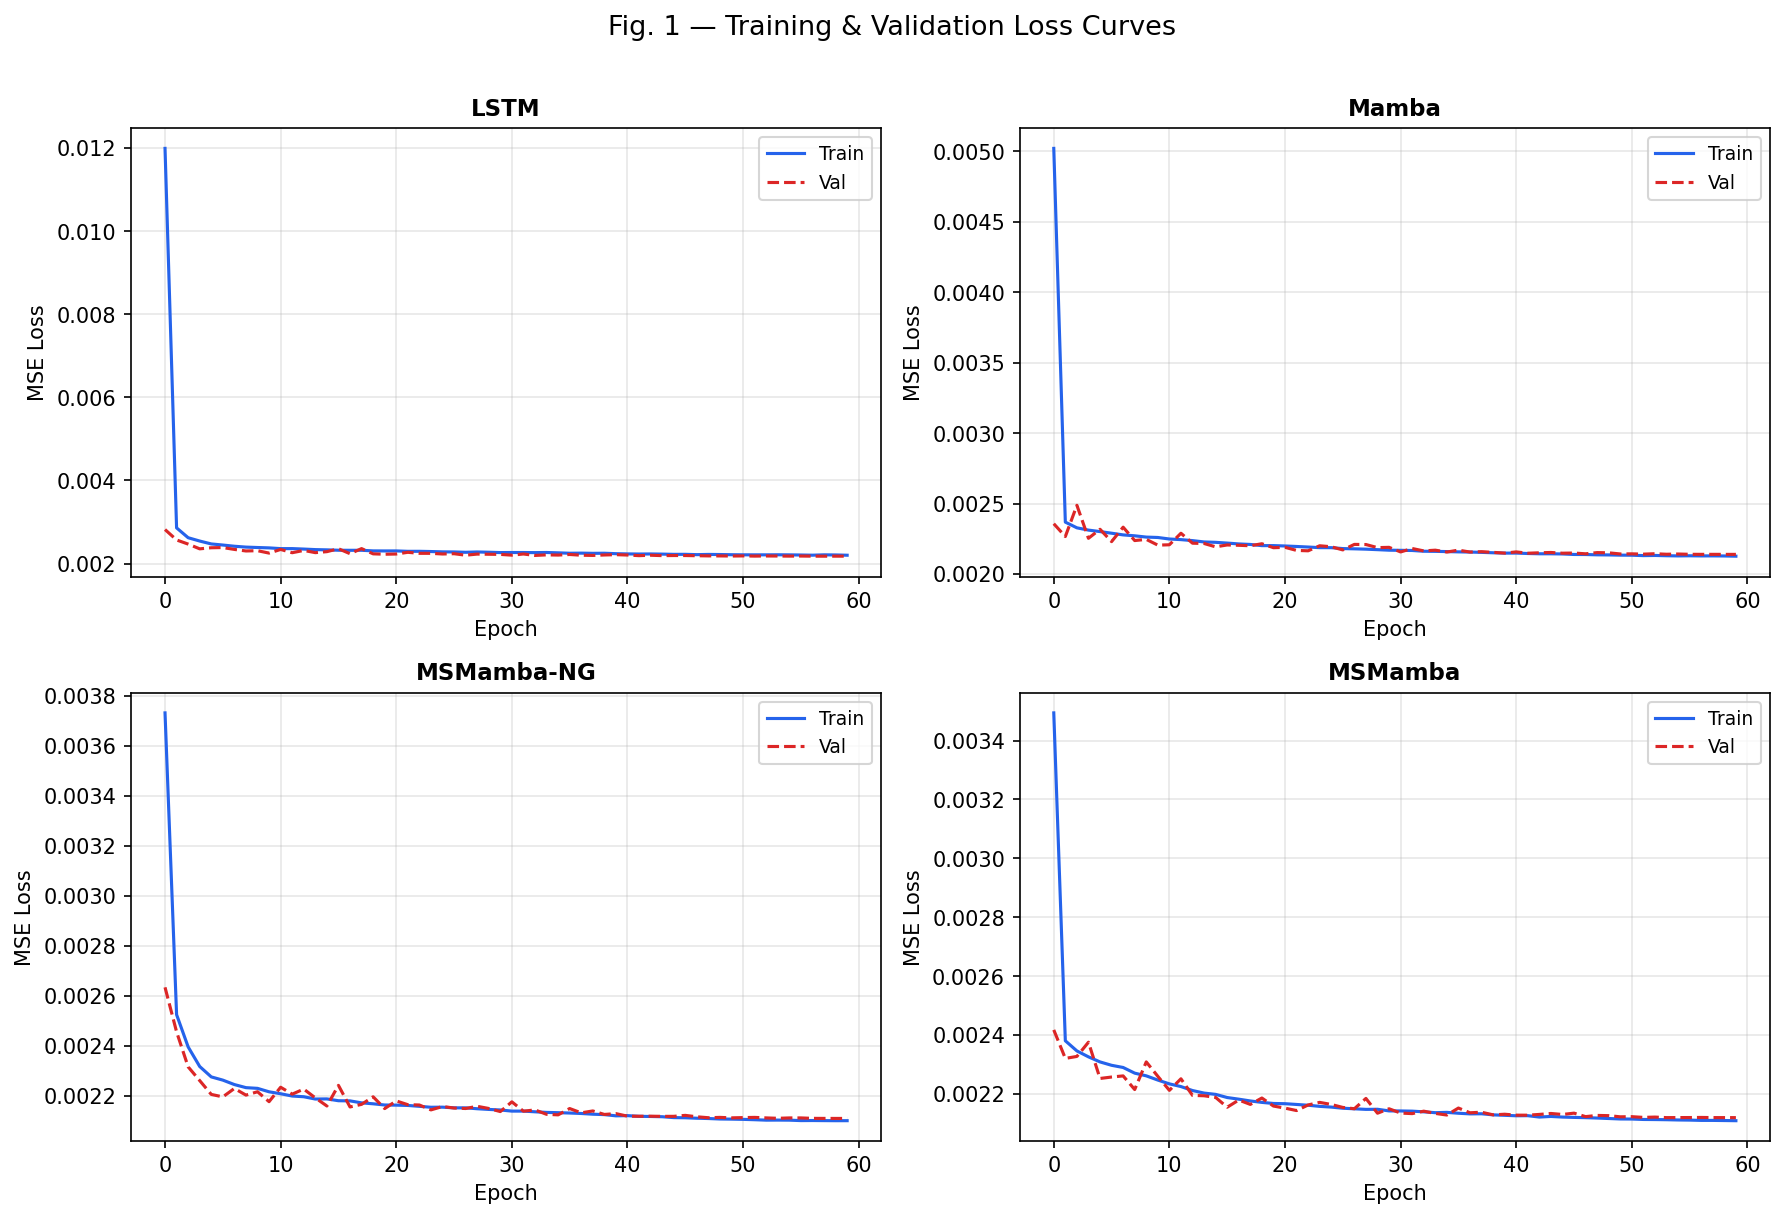

✅  fig1_loss_curves saved


KeyError: 'PI-LSTM'

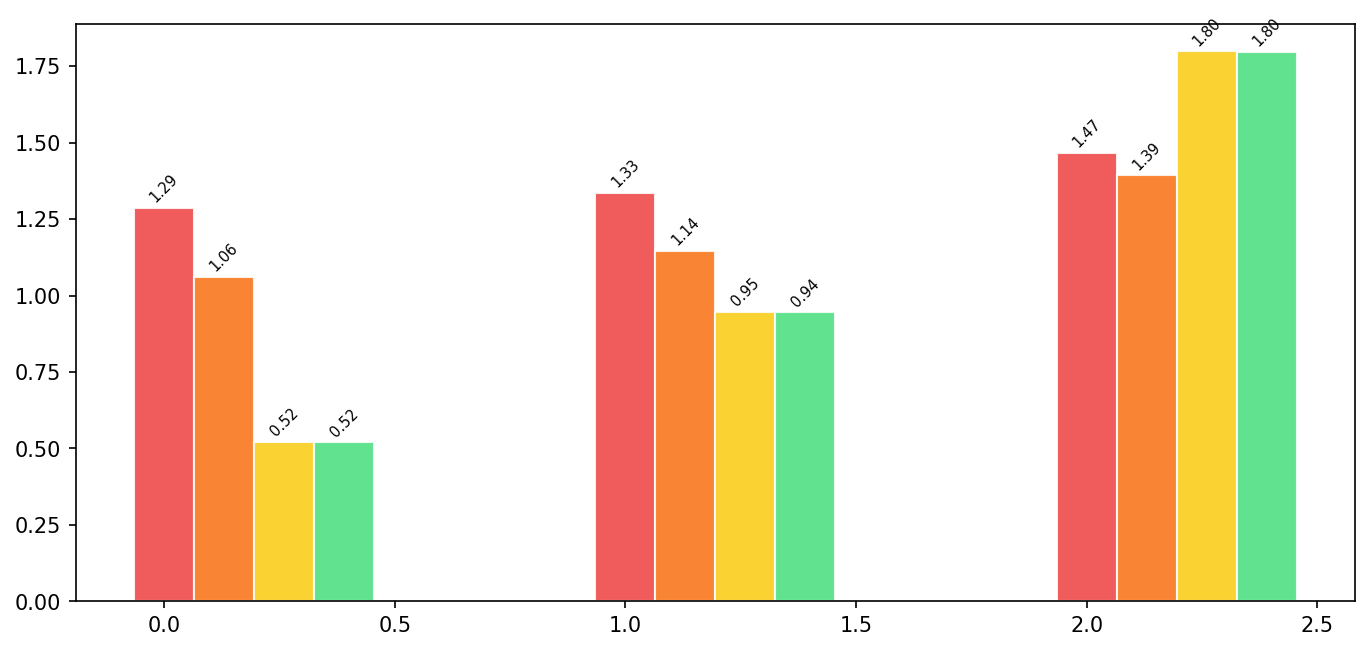

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 ── Figure 1: Loss Curves (all models, 2×2 grid)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=150)
axes = axes.flatten()
palette = {'train': '#2563EB', 'val': '#DC2626'}

for ax, (name, (h_tr, h_va)) in zip(axes, histories.items()):
    ax.plot(h_tr, color=palette['train'], lw=1.5, label='Train')
    ax.plot(h_va, color=palette['val'],   lw=1.5, label='Val', ls='--')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

fig.suptitle('Fig. 1 — Training & Validation Loss Curves', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig1_loss_curves.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig1_loss_curves.png', dpi=300, bbox_inches='tight')
plt.show(); print("✅  fig1_loss_curves saved")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 ── Figure 2: RMSE Bar Chart (all methods × all delays)
# ─────────────────────────────────────────────────────────────────────────────

all_m_keys   = ['_DEL', '_KF', 'LSTM', 'Mamba', 'PI-LSTM', 'PI-Mamba']
all_m_labels = ['Delayed\n(No Comp.)', 'Kalman\nFilter',
                'LSTM', 'Mamba\n(no physics)', 'PI-LSTM', 'PI-Mamba\n(Proposed)']
colors       = ['#EF4444', '#F97316', '#FACC15', '#4ADE80', '#60A5FA', '#A78BFA']

x     = np.arange(len(DELAY_LABELS))
width = 0.13
fig, ax = plt.subplots(figsize=(11, 5), dpi=150)

for i, (mkey, mlabel, color) in enumerate(zip(all_m_keys, all_m_labels, colors)):
    vals = [results[mkey][d] for d in DELAY_LABELS]
    bars = ax.bar(x + i * width, vals, width,
                  label=mlabel, color=color, alpha=0.88, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(DELAY_LABELS, fontsize=11)
ax.set_xlabel('Network Latency Condition', fontsize=11)
ax.set_ylabel('RMSE (mm)', fontsize=11)
ax.set_title('Fig. 2 — RMSE Comparison Under Different Latency Conditions', fontsize=12)
ax.legend(fontsize=8, ncol=6, loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_rmse_comparison.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig2_rmse_comparison.png', dpi=300, bbox_inches='tight')
plt.show(); print("✅  fig2_rmse_comparison saved")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 ── Figure 3: 3D Trajectory (200ms condition)
# ─────────────────────────────────────────────────────────────────────────────

mdl_pi = models['PI-Mamba']
mdl_pi.eval()

# Get a contiguous test segment for visualisation
vis_start, vis_end = SEQ_LEN, SEQ_LEN + 500
gt_vis  = traj[vis_start:vis_end]
del_vis = DELAY_CFG['200ms'][0][vis_start:vis_end]
kf_vis  = run_kalman(traj, 6)[vis_start:vis_end]

# LSTM prediction on the same window
X_vis   = torch.tensor(
    scaler.transform(traj[vis_start - SEQ_LEN: vis_end - PRED_LEN])
).unfold(0, SEQ_LEN, 1)[:, :, :].permute(0, 2, 1).float()
# safer approach: use stored test predictions
# ── 新代码：在连续窗口上滑动预测，保证时序正确 ──
mdl_pi.eval()
vis_preds = []
traj_scaled = scaler.transform(traj).astype(np.float32)

with torch.no_grad():
    for i in range(vis_start - SEQ_LEN, vis_end - PRED_LEN):
        x_win = torch.tensor(traj_scaled[i: i+SEQ_LEN]).unsqueeze(0).to(device)  # (1, 30, 3)
        pred  = mdl_pi(x_win).cpu().numpy()  # (1, 6, 3)
        vis_preds.append(pred[0, -1, :])     # 取第 6 步（200ms 后）

vis_preds = np.array(vis_preds)              # (500, 3)
lstm_vis_raw = scaler.inverse_transform(vis_preds)  # 逆归一化回 m

if len(lstm_vis_raw) < len(gt_vis):
    pad = np.tile(lstm_vis_raw[-1], (len(gt_vis)-len(lstm_vis_raw), 1))
    lstm_vis_raw = np.vstack([lstm_vis_raw, pad])

plot_trajs  = [gt_vis, del_vis, kf_vis, lstm_vis_raw[:len(gt_vis)]]
plot_labels = ['Ground Truth', 'Delayed 200ms\n(No Comp.)',
               'Kalman Filter', 'PI-Mamba\n(Proposed)']
plot_colors = ['#1E3A5F', '#EF4444', '#F59E0B', '#7C3AED']

fig = plt.figure(figsize=(14, 5), dpi=150)
for i, (trj, label, c) in enumerate(zip(plot_trajs, plot_labels, plot_colors)):
    ax = fig.add_subplot(1, 4, i+1, projection='3d')
    ax.plot(trj[:,0]*100, trj[:,1]*100, trj[:,2]*100,
            color=c, lw=1.2, alpha=0.9)
    ax.scatter(*trj[0]*100,  color='k',  s=20)
    ax.scatter(*trj[-1]*100, color=c,    s=30, marker='*')
    ax.set_title(label, fontsize=9, pad=6)
    ax.set_xlabel('X (cm)', fontsize=7); ax.set_ylabel('Y (cm)', fontsize=7)
    ax.set_zlabel('Z (cm)', fontsize=7); ax.tick_params(labelsize=6)

fig.suptitle('Fig. 3 — 3D Surgical Trajectory (200ms Latency Condition)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig3_3d_trajectory.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig3_3d_trajectory.png', dpi=300, bbox_inches='tight')
plt.show(); print("✅  fig3_3d_trajectory saved")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 ── Figure 4: Ablation — Physics Loss Components Over Training
# ─────────────────────────────────────────────────────────────────────────────

# Re-train PI-Mamba logging individual loss terms
pi_model_log = PIMamba(D_MODEL, D_STATE, N_LAYERS, SEQ_LEN, PRED_LEN).to(device)
pi_loss_fn   = PhysicsInformedLoss()
opt_log      = torch.optim.Adam(pi_model_log.parameters(), lr=LR, weight_decay=1e-5)

log_data = {k: [] for k in ['data','vel','acc','jerk','total']}

print("\n  Logging PI-Mamba loss components ...")
for ep in range(1, EPOCHS + 1):
    pi_model_log.train()
    ep_log = {k: 0.0 for k in log_data}
    for X, Y in train_loader:
        X, Y = X.to(device), Y.to(device)
        opt_log.zero_grad()
        pred = pi_model_log(X)
        ld = pi_loss_fn(pred, Y, X)
        ld['total'].backward()
        nn.utils.clip_grad_norm_(pi_model_log.parameters(), 1.0)
        opt_log.step()
        for k in ep_log: ep_log[k] += ld[k] if k=='total' else ld[k]
    for k in log_data: log_data[k].append(ep_log[k] / len(train_loader))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

# Left: total vs data loss
ax = axes[0]
ax.plot(log_data['total'], color='#7C3AED', lw=2, label='L_total')
ax.plot(log_data['data'],  color='#2563EB', lw=1.5, ls='--', label='L_data')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('(a) Total vs Data Loss', fontsize=11)

# Right: physics components
ax = axes[1]
ax.plot(log_data['vel'],  color='#10B981', lw=1.5, label='L_vel  (velocity)')
ax.plot(log_data['acc'],  color='#F59E0B', lw=1.5, label='L_acc  (acceleration cap)')
ax.plot(log_data['jerk'], color='#EF4444', lw=1.5, label='L_jerk (minimum-jerk)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('(b) Physics Constraint Components', fontsize=11)

fig.suptitle('Fig. 4 — Physics-Informed Loss Components During Training', fontsize=12)
plt.tight_layout()
plt.savefig('fig4_physics_loss.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig4_physics_loss.png', dpi=300, bbox_inches='tight')
plt.show(); print("✅  fig4_physics_loss saved")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 ── Figure 5: Inference Latency Distribution
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)
pal_lat   = {'LSTM':'#60A5FA','Mamba':'#4ADE80','PI-LSTM':'#FACC15','PI-Mamba':'#A78BFA'}

# Left: overlapping histograms
ax = axes[0]
for name, times in lat.items():
    ax.hist(times, bins=40, alpha=0.55, label=name, color=pal_lat[name], edgecolor='none')
ax.axvline(10, color='red', lw=2, ls='--', label='10ms threshold')
ax.set_xlabel('Inference Time (ms)'); ax.set_ylabel('Frequency')
ax.set_title('(a) Latency Distribution', fontsize=11); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Right: box plot
ax = axes[1]
bp = ax.boxplot([lat[n] for n in lat], labels=list(lat.keys()),
                patch_artist=True, notch=True)
for patch, name in zip(bp['boxes'], lat.keys()):
    patch.set_facecolor(pal_lat[name]); patch.set_alpha(0.7)
ax.axhline(10, color='red', lw=2, ls='--', label='10ms threshold')
ax.set_ylabel('Inference Time (ms)'); ax.set_title('(b) Latency Box Plot', fontsize=11)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

fig.suptitle('Fig. 5 — Inference Latency Benchmark (CPU, 1000 runs)', fontsize=12)
plt.tight_layout()
plt.savefig('fig5_latency.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig5_latency.png', dpi=300, bbox_inches='tight')
plt.show(); print("✅  fig5_latency saved")



# CELL 17 ── Final Summary Table

In [ ]:
print("\n" + "═"*68)
print("  TABLE I — RMSE Comparison (mm)")
print("═"*68)
print(f"  {'Method':<22} {'100ms':>8} {'200ms':>8} {'500ms':>8}  {'Params':>8}")
print("  " + "─"*58)

param_map = {
    '_DEL':    '—',
    '_KF':     '—',
    'LSTM':    f"{count_params(models['LSTM']):,}",
    'Mamba':   f"{count_params(models['Mamba']):,}",
    'PI-LSTM': f"{count_params(models['PI-LSTM']):,}",
    'PI-Mamba':f"{count_params(models['PI-Mamba']):,}",
}
for mkey, mlabel in zip(all_m_keys, labels_print):
    mlabel_clean = mlabel.replace('\n', ' ')
    vals = [results[mkey][d] for d in DELAY_LABELS]
    print(f"  {mlabel_clean:<22} {vals[0]:>8.4f} {vals[1]:>8.4f} {vals[2]:>8.4f}  "
          f"{param_map[mkey]:>8}")

print("═"*68)
print("\n  TABLE II — Inference Latency (CPU, 1000 runs)\n" + "─"*50)
print(f"  {'Model':<12} {'Mean (ms)':>10} {'Std (ms)':>9} {'P95 (ms)':>9}  Real-time")
print("  " + "─"*46)
for name, times in lat.items():
    ok = '✅ YES' if times.mean() < 10 else '❌ NO'
    print(f"  {name:<12} {times.mean():>10.3f} {times.std():>9.3f} "
          f"{np.percentile(times,95):>9.3f}  {ok}")
print("═"*68)

print("""
✅  All done!  Figures saved to current Colab directory:
   fig1_loss_curves.pdf       → Section 5 (Training dynamics)
   fig2_rmse_comparison.pdf   → Section 5 (Main quantitative result)
   fig3_3d_trajectory.pdf     → Section 5 (Visual demonstration)
   fig4_physics_loss.pdf      → Section 5 (Ablation: physics components)
   fig5_latency.pdf           → Section 5 (Real-time proof)

Download via: Files panel (left sidebar) → right-click → Download
""")
